In [11]:
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Charger le CSV
df = pd.read_csv("../data/dataset_selection_sans_leger.csv")

# Aperçu du dataset
print("Aperçu du dataset :")
print(df.head())

print(f"\nNombre total d'images : {len(df)}")

# Répartition des labels
class_counts = df['label'].value_counts()
print("\nRépartition des labels :")
print(class_counts)

Aperçu du dataset :
                                                path     label
0  /home/theo/mathis/Memoire/data/glaucome/ORIGA/...  glaucome
1  /home/theo/mathis/Memoire/data/glaucome/LAG/LA...  glaucome
2  /home/theo/mathis/Memoire/data/glaucome/LAG/LA...  glaucome
3  /home/theo/mathis/Memoire/data/glaucome/LAG/LA...  glaucome
4  /home/theo/mathis/Memoire/data/glaucome/LAG/LA...  glaucome

Nombre total d'images : 6323

Répartition des labels :
label
glaucome    1581
mda         1581
diabete     1581
normaux     1580
Name: count, dtype: int64


In [12]:
from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split(
    df,
    test_size=0.1,
    stratify=df['label'],
    random_state=42
)

print("Tailles des splits :")
print(f"Train : {len(df_train)}")
print(f"Test : {len(df_test)}")

# Mapping label -> id
classes = sorted(df['label'].unique().tolist())
label_to_id = {c: i for i, c in enumerate(classes)}
print(f"\nClasses : {classes}")

Tailles des splits :
Train : 5690
Test : 633

Classes : ['diabete', 'glaucome', 'mda', 'normaux']


In [13]:
# Fonction pour enlever les bords noirs
def crop_black_border(img, thr=10, pad=10):
    if len(img.shape) == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        gray = img
    
    mask = gray > thr
    if not mask.any():
        return img
    
    ys, xs = np.where(mask)
    y0, y1 = ys.min(), ys.max()
    x0, x1 = xs.min(), xs.max()
    
    y0 = max(0, y0 - pad)
    x0 = max(0, x0 - pad)
    y1 = min(img.shape[0] - 1, y1 + pad)
    x1 = min(img.shape[1] - 1, x1 + pad)
    
    return img[y0:y1+1, x0:x1+1]

def load_image(path, size=(128, 128)):
    img = cv2.imread(path)
    if img is None:
        return None
    img = crop_black_border(img, thr=10, pad=10)
    img = cv2.resize(img, size)
    return img

def augment_image(img):
    aug = []
    h, w = img.shape[:2]
    for angle in [-15, 15]:
        M = cv2.getRotationMatrix2D((w//2, h//2), angle, 1)
        aug.append(cv2.warpAffine(img, M, (w, h)))
    aug.append(cv2.flip(img, 1))   # flip horizontal
    aug.append(cv2.flip(img, 0))   # flip vertical
    aug.append(np.clip(img.astype(np.float32) * 1.2 - 15, 0, 255).astype(np.uint8))
    return aug

print("Fonctions de prétraitement définies ✓")

Fonctions de prétraitement définies ✓


In [14]:
from skimage.feature import hog

def extract_hog_features(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    features = hog(
        gray,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm='L2-Hys',
        feature_vector=True
    )
    return features

def extract_pixel_features(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return gray.flatten().astype(np.float32) / 255.0

print("Fonctions d'extraction de features définies ✓")
print(f"HOG sur image 128x128 donne {extract_hog_features(np.zeros((128, 128, 3), dtype=np.uint8)).shape[0]} features")
print(f"Pixels aplatis sur image 128x128 donne {128*128} features")

Fonctions d'extraction de features définies ✓
HOG sur image 128x128 donne 8100 features
Pixels aplatis sur image 128x128 donne 16384 features


In [15]:
def extract_all_features(df_subset, extract_func, augment=False):
    features = []
    labels = []
    valid_indices = []
    
    for idx, row in tqdm(df_subset.iterrows(), total=len(df_subset)):
        img = load_image(row['path'])
        if img is None:
            continue
        
        features.append(extract_func(img))
        labels.append(label_to_id[row['label']])
        valid_indices.append(idx)
        if augment:
            for aug_img in augment_image(img):
                features.append(extract_func(aug_img))
                labels.append(label_to_id[row['label']])
                valid_indices.append(idx)
    
    return np.array(features), np.array(labels), valid_indices

print("Extraction des features pixels (pour PCA)...")
X_train_pixels, y_train, _ = extract_all_features(df_train, extract_pixel_features, augment=True)
X_test_pixels, y_test, _ = extract_all_features(df_test, extract_pixel_features)

print(f"\nShape X_train_pixels: {X_train_pixels.shape}")
print(f"Shape X_test_pixels: {X_test_pixels.shape}")

Extraction des features pixels (pour PCA)...


  3%|▎         | 173/5690 [00:06<02:23, 38.46it/s][ WARN:0@1354.789] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 11 (0xb) encountered
[ WARN:0@1354.789] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 59932 (0xea1c) encountered
  4%|▍         | 226/5690 [00:07<02:09, 42.24it/s][ WARN:0@1356.405] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 11 (0xb) encountered
[ WARN:0@1356.405] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 59932 (0xea1c) encountered
  7%|▋         | 374/5690 [00:12<03:08, 28.21it/s][ WARN:0@1361.124] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 11 (0xb) encountered
[ WARN:0@1361.124] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 59932 (0xea1c) encountered
  7%|▋         | 378/5690 [00:12<03:19, 26.63it/s][ WARN:0@1361.355] global grfmt_tiff.cpp:122 TIFF_Warnin


Shape X_train_pixels: (34140, 16384)
Shape X_test_pixels: (633, 16384)


In [16]:
print("Extraction des features HOG...")
X_train_hog, _, _ = extract_all_features(df_train, extract_hog_features, augment=True)
X_test_hog, _, _ = extract_all_features(df_test, extract_hog_features)

X_train_hog = X_train_hog.astype(np.float32)
X_test_hog = X_test_hog.astype(np.float32)

print(f"\nShape X_train_hog: {X_train_hog.shape}")
print(f"Shape X_test_hog: {X_test_hog.shape}")

Extraction des features HOG...


  3%|▎         | 173/5690 [00:08<03:26, 26.74it/s][ WARN:0@1562.940] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 11 (0xb) encountered
[ WARN:0@1562.940] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 59932 (0xea1c) encountered
  4%|▍         | 231/5690 [00:11<03:18, 27.44it/s][ WARN:0@1565.400] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 11 (0xb) encountered
[ WARN:0@1565.400] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 59932 (0xea1c) encountered
  7%|▋         | 373/5690 [00:17<04:23, 20.15it/s][ WARN:0@1572.013] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 11 (0xb) encountered
[ WARN:0@1572.013] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 59932 (0xea1c) encountered
  7%|▋         | 379/5690 [00:17<04:56, 17.91it/s][ WARN:0@1572.320] global grfmt_tiff.cpp:122 TIFF_Warnin


Shape X_train_hog: (34140, 8100)
Shape X_test_hog: (633, 8100)


In [17]:
import gc
import ctypes
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler_pixels = StandardScaler()
X_train_pixels_scaled = scaler_pixels.fit_transform(X_train_pixels).astype(np.float32)
X_test_pixels_scaled = scaler_pixels.transform(X_test_pixels).astype(np.float32)
del X_train_pixels, X_test_pixels
gc.collect()

print(f"Shape X_train_pixels_scaled: {X_train_pixels_scaled.shape}")
print("PCA sera testée avec différents n_components dans le RandomizedSearchCV")

Shape X_train_pixels_scaled: (34140, 16384)
PCA sera testée avec différents n_components dans le RandomizedSearchCV


In [18]:
scaler_hog = StandardScaler()
X_train_hog_scaled = scaler_hog.fit_transform(X_train_hog).astype(np.float32)
X_test_hog_scaled = scaler_hog.transform(X_test_hog).astype(np.float32)
del X_train_hog, X_test_hog
gc.collect()

n_pixel_features = X_train_pixels_scaled.shape[1]
n_hog_features = X_train_hog_scaled.shape[1]

X_train_combined_raw = np.hstack([X_train_pixels_scaled, X_train_hog_scaled])
X_test_combined_raw = np.hstack([X_test_pixels_scaled, X_test_hog_scaled])

# Libérer X_train_hog_scaled immédiatement — il sera reconstruit depuis combined dans la cell 10
del X_train_hog_scaled
gc.collect()
ctypes.CDLL("libc.so.6").malloc_trim(0)

print(f"Shape X_train_combined_raw: {X_train_combined_raw.shape}")
print(f"  - Colonnes pixels: 0 à {n_pixel_features - 1}")
print(f"  - Colonnes HOG: {n_pixel_features} à {n_pixel_features + n_hog_features - 1}")

Shape X_train_combined_raw: (34140, 24484)
  - Colonnes pixels: 0 à 16383
  - Colonnes HOG: 16384 à 24483


In [19]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Paramètres XGBoost à explorer
xgb_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.85, 1.0],
    'colsample_bytree': [0.7, 0.85, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.5],
    'reg_alpha': [0, 0.1, 1.0],
    'reg_lambda': [1.0, 2.0, 5.0]
}

# Valeurs de PCA à tester
pca_components = [30, 50, 75, 100, 125, 150]

print("Paramètres XGBoost à tester:")
for key, values in xgb_params.items():
    print(f"  {key}: {values}")
print(f"\nComposantes PCA à tester: {pca_components}")

Paramètres XGBoost à tester:
  n_estimators: [100, 200, 300]
  max_depth: [3, 5, 7]
  learning_rate: [0.01, 0.05, 0.1, 0.2]
  subsample: [0.7, 0.85, 1.0]
  colsample_bytree: [0.7, 0.85, 1.0]
  min_child_weight: [1, 3, 5]
  gamma: [0, 0.1, 0.5]
  reg_alpha: [0, 0.1, 1.0]
  reg_lambda: [1.0, 2.0, 5.0]

Composantes PCA à tester: [30, 50, 75, 100, 125, 150]


In [20]:
results = {}

# ============================================================
# 1) PCA seul: Pipeline(PCA -> XGBoost)
# ============================================================
print("="*60)
print("RandomizedSearch pour: PCA (avec n_components dans la grille)")
print("="*60)

pipe_pca = Pipeline([
    ('pca', PCA(random_state=42)),
    ('xgb', XGBClassifier(
        random_state=42,
        eval_metric='mlogloss',
        use_label_encoder=False,
        device='cuda',
        tree_method='hist'
    ))
])

param_grid_pca = {
    'pca__n_components': pca_components,
    **{f'xgb__{k}': v for k, v in xgb_params.items()}
}

grid_pca = RandomizedSearchCV(
    pipe_pca, param_grid_pca,
    n_iter=75, cv=3, scoring='accuracy',
    n_jobs=1, verbose=1, random_state=42
)
grid_pca.fit(X_train_pixels_scaled, y_train)

print(f"\nMeilleurs paramètres: {grid_pca.best_params_}")
print(f"Meilleur score CV: {grid_pca.best_score_:.4f}")

results['PCA'] = {
    'grid_search': grid_pca,
    'best_model': grid_pca.best_estimator_,
    'best_params': grid_pca.best_params_,
    'best_cv_score': grid_pca.best_score_,
    'X_test': X_test_pixels_scaled
}

del X_train_pixels_scaled
gc.collect()
ctypes.CDLL("libc.so.6").malloc_trim(0)

RandomizedSearch pour: PCA (avec n_components dans la grille)
Fitting 3 folds for each of 75 candidates, totalling 225 fits

Meilleurs paramètres: {'xgb__subsample': 0.7, 'xgb__reg_lambda': 5.0, 'xgb__reg_alpha': 0, 'xgb__n_estimators': 200, 'xgb__min_child_weight': 1, 'xgb__max_depth': 7, 'xgb__learning_rate': 0.2, 'xgb__gamma': 0.1, 'xgb__colsample_bytree': 0.85, 'pca__n_components': 125}
Meilleur score CV: 0.8040


1

In [21]:
# ============================================================
# 2) HOG seul: XGBoost directement
# ============================================================
print("="*60)
print("RandomizedSearch pour: HOG")
print("="*60)

# Reconstruire X_train_hog depuis combined (évite de garder les 2 arrays séparément en RAM)
X_train_hog_for_search = np.ascontiguousarray(X_train_combined_raw[:, n_pixel_features:])

xgb_hog = XGBClassifier(
    random_state=42,
    eval_metric='mlogloss',
    use_label_encoder=False,
    device='cuda',
    tree_method='hist'
)

grid_hog = RandomizedSearchCV(
    xgb_hog, xgb_params,
    n_iter=75, cv=3, scoring='accuracy',
    n_jobs=1, verbose=1, random_state=42
)
grid_hog.fit(X_train_hog_for_search, y_train)

print(f"\nMeilleurs paramètres: {grid_hog.best_params_}")
print(f"Meilleur score CV: {grid_hog.best_score_:.4f}")

results['HOG'] = {
    'grid_search': grid_hog,
    'best_model': grid_hog.best_estimator_,
    'best_params': grid_hog.best_params_,
    'best_cv_score': grid_hog.best_score_,
    'X_test': X_test_hog_scaled
}

del X_train_hog_for_search
gc.collect()
ctypes.CDLL("libc.so.6").malloc_trim(0)

RandomizedSearch pour: HOG
Fitting 3 folds for each of 75 candidates, totalling 225 fits

Meilleurs paramètres: {'subsample': 1.0, 'reg_lambda': 1.0, 'reg_alpha': 1.0, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 7, 'learning_rate': 0.2, 'gamma': 0, 'colsample_bytree': 0.7}
Meilleur score CV: 0.8273


1

In [22]:
# ============================================================
# 3) PCA + HOG: ColumnTransformer(PCA sur pixels, passthrough HOG) -> XGBoost
# ============================================================
print("="*60)
print("RandomizedSearch pour: PCA + HOG (avec n_components dans la grille)")
print("="*60)

pixel_cols = list(range(n_pixel_features))
hog_cols = list(range(n_pixel_features, n_pixel_features + n_hog_features))

pipe_combined = Pipeline([
    ('features', ColumnTransformer([
        ('pca', PCA(random_state=42), pixel_cols),
        ('hog', 'passthrough', hog_cols)
    ])),
    ('xgb', XGBClassifier(
        random_state=42,
        eval_metric='mlogloss',
        use_label_encoder=False,
        device='cuda',
        tree_method='hist'
    ))
])

param_grid_combined = {
    'features__pca__n_components': pca_components,
    **{f'xgb__{k}': v for k, v in xgb_params.items()}
}

grid_combined = RandomizedSearchCV(
    pipe_combined, param_grid_combined,
    n_iter=75, cv=3, scoring='accuracy',
    n_jobs=1, verbose=1, random_state=42
)
grid_combined.fit(X_train_combined_raw, y_train)

print(f"\nMeilleurs paramètres: {grid_combined.best_params_}")
print(f"Meilleur score CV: {grid_combined.best_score_:.4f}")

results['PCA + HOG'] = {
    'grid_search': grid_combined,
    'best_model': grid_combined.best_estimator_,
    'best_params': grid_combined.best_params_,
    'best_cv_score': grid_combined.best_score_,
    'X_test': X_test_combined_raw
}

RandomizedSearch pour: PCA + HOG (avec n_components dans la grille)
Fitting 3 folds for each of 75 candidates, totalling 225 fits

Meilleurs paramètres: {'xgb__subsample': 1.0, 'xgb__reg_lambda': 2.0, 'xgb__reg_alpha': 0, 'xgb__n_estimators': 300, 'xgb__min_child_weight': 1, 'xgb__max_depth': 5, 'xgb__learning_rate': 0.2, 'xgb__gamma': 0.1, 'xgb__colsample_bytree': 0.85, 'features__pca__n_components': 50}
Meilleur score CV: 0.8333


In [23]:
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

print("\n" + "="*70)
print("ÉVALUATION SUR LE JEU DE TEST")
print("="*70)

comparison_data = []

for name, data in results.items():
    model = data['best_model']
    X_test = data['X_test']
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    bacc = balanced_accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)

    results[name]['test_accuracy'] = acc
    results[name]['test_balanced_accuracy'] = bacc
    results[name]['test_f1'] = f1
    results[name]['y_pred'] = y_pred

    comparison_data.append({
        'Approche': name,
        'CV Score': data['best_cv_score'],
        'Test Accuracy': acc,
        'Balanced Acc': bacc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1
    })

    print(f"\n--- {name} ---")
    print(f"Meilleurs paramètres: {data['best_params']}")
    print(f"Test Accuracy: {acc:.4f}")
    print(f"Balanced Accuracy: {bacc:.4f}")
    print(f"F1 Score (macro): {f1:.4f}")

comparison_df = pd.DataFrame(comparison_data).round(4)

print("\n" + "="*70)
print("TABLEAU COMPARATIF DES 3 APPROCHES")
print("="*70)
print(comparison_df.to_string(index=False))

best_approach = comparison_df.loc[comparison_df['Test Accuracy'].idxmax(), 'Approche']
print(f"\n✅ Meilleure approche: {best_approach}")


ÉVALUATION SUR LE JEU DE TEST

--- PCA ---
Meilleurs paramètres: {'xgb__subsample': 0.7, 'xgb__reg_lambda': 5.0, 'xgb__reg_alpha': 0, 'xgb__n_estimators': 200, 'xgb__min_child_weight': 1, 'xgb__max_depth': 7, 'xgb__learning_rate': 0.2, 'xgb__gamma': 0.1, 'xgb__colsample_bytree': 0.85, 'pca__n_components': 125}
Test Accuracy: 0.8120
Balanced Accuracy: 0.8119
F1 Score (macro): 0.8043

--- HOG ---
Meilleurs paramètres: {'subsample': 1.0, 'reg_lambda': 1.0, 'reg_alpha': 1.0, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 7, 'learning_rate': 0.2, 'gamma': 0, 'colsample_bytree': 0.7}
Test Accuracy: 0.8452
Balanced Accuracy: 0.8450
F1 Score (macro): 0.8336

--- PCA + HOG ---
Meilleurs paramètres: {'xgb__subsample': 1.0, 'xgb__reg_lambda': 2.0, 'xgb__reg_alpha': 0, 'xgb__n_estimators': 300, 'xgb__min_child_weight': 1, 'xgb__max_depth': 5, 'xgb__learning_rate': 0.2, 'xgb__gamma': 0.1, 'xgb__colsample_bytree': 0.85, 'features__pca__n_components': 50}
Test Accuracy: 0.8531
Balanced Acc

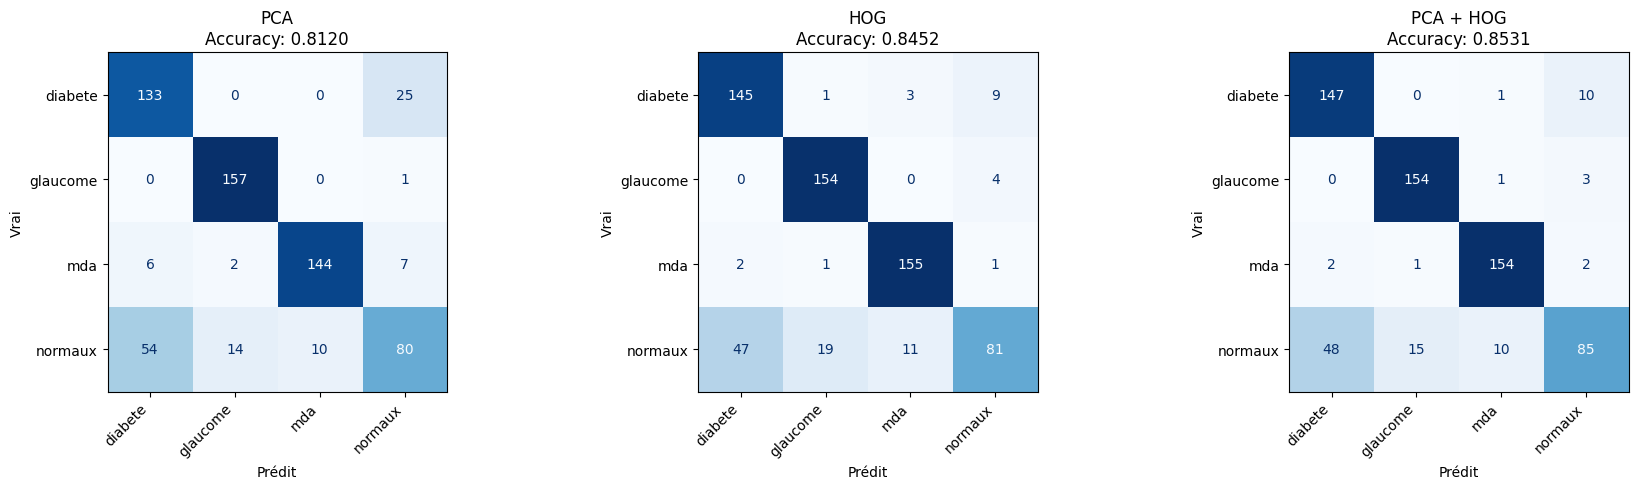

In [24]:
# Matrices de confusion pour chaque approche
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, data) in enumerate(results.items()):
    y_pred = data['y_pred']
    cm = confusion_matrix(y_test, y_pred, labels=list(range(len(classes))))
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    disp.plot(ax=axes[idx], values_format='d', cmap='Blues', colorbar=False)
    axes[idx].set_title(f'{name}\nAccuracy: {data["test_accuracy"]:.4f}')
    axes[idx].set_xlabel('Prédit')
    axes[idx].set_ylabel('Vrai')
    plt.setp(axes[idx].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [25]:
# Rapport de classification détaillé pour la meilleure approche
print("\n" + "="*70)
print(f"RAPPORT DÉTAILLÉ POUR LA MEILLEURE APPROCHE: {best_approach}")
print("="*70)

best_data = results[best_approach]
print(f"\nMeilleurs paramètres trouvés:")
for param, value in best_data['best_params'].items():
    print(f"  {param}: {value}")

print("\nRapport de classification:")
print(classification_report(y_test, best_data['y_pred'], target_names=classes, zero_division=0))


RAPPORT DÉTAILLÉ POUR LA MEILLEURE APPROCHE: PCA + HOG

Meilleurs paramètres trouvés:
  xgb__subsample: 1.0
  xgb__reg_lambda: 2.0
  xgb__reg_alpha: 0
  xgb__n_estimators: 300
  xgb__min_child_weight: 1
  xgb__max_depth: 5
  xgb__learning_rate: 0.2
  xgb__gamma: 0.1
  xgb__colsample_bytree: 0.85
  features__pca__n_components: 50

Rapport de classification:
              precision    recall  f1-score   support

     diabete       0.75      0.93      0.83       158
    glaucome       0.91      0.97      0.94       158
         mda       0.93      0.97      0.95       159
     normaux       0.85      0.54      0.66       158

    accuracy                           0.85       633
   macro avg       0.86      0.85      0.84       633
weighted avg       0.86      0.85      0.84       633



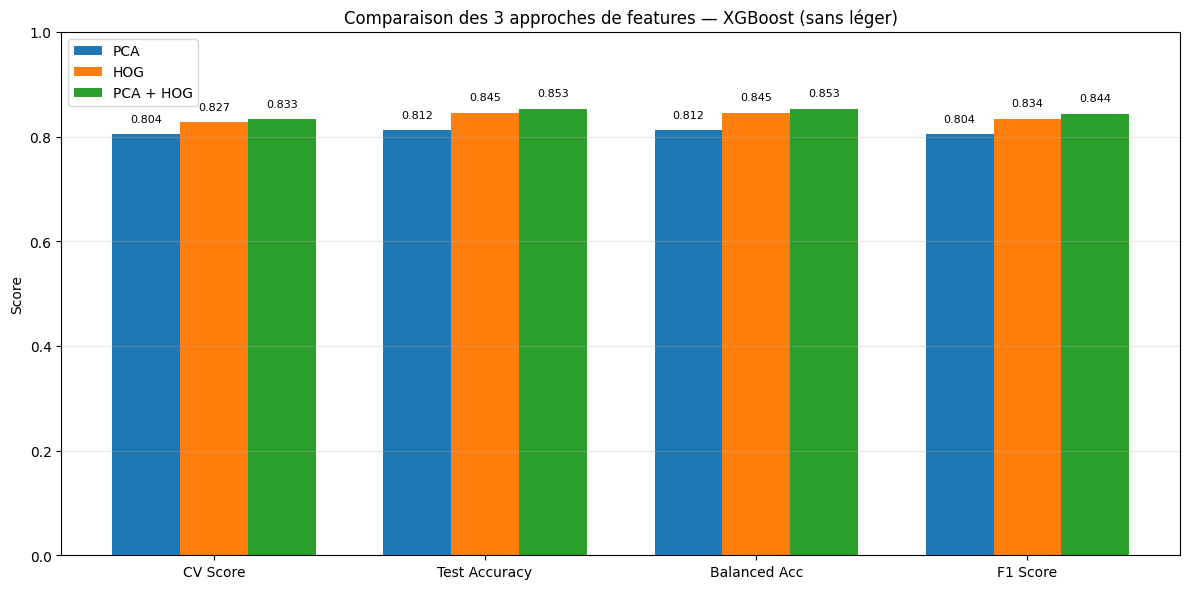

In [26]:
# Graphique comparatif des performances
metrics = ['CV Score', 'Test Accuracy', 'Balanced Acc', 'F1 Score']
x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

for i, approach in enumerate(['PCA', 'HOG', 'PCA + HOG']):
    row = comparison_df[comparison_df['Approche'] == approach].iloc[0]
    values = [row['CV Score'], row['Test Accuracy'], row['Balanced Acc'], row['F1 Score']]
    ax.bar(x + i*width, values, width, label=approach)

ax.set_ylabel('Score')
ax.set_title('Comparaison des 3 approches de features — XGBoost (sans léger)')
ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)

for i, approach in enumerate(['PCA', 'HOG', 'PCA + HOG']):
    row = comparison_df[comparison_df['Approche'] == approach].iloc[0]
    values = [row['CV Score'], row['Test Accuracy'], row['Balanced Acc'], row['F1 Score']]
    for j, v in enumerate(values):
        ax.text(x[j] + i*width, v + 0.02, f'{v:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()